# Cross-Lingual Language Alignment

This notebook investigates whether multilingual embeddings organize sentences according to semantic meaning rather than \
language identity.

Reasearch Question:

Do semantically equivalent English, German, and Russian sentences occupy similar regions of the embedding space?

This experiment extends the previous embedding exploration by visualizing the multilingual semantic space using \
dimensionality reduction.

Experiments:

- Generate multilingual sentence embeddings
- Apply PCA dimensionality reduction
- Visualize semantic relationships across languages
- Compare semantic clusters with language identity
- Inspect potential alignment and separation patterns

This experiment addresses the project's fourth major experiment:

**Semantic Space Visulaization**

The goal is to provide a visual diagnostic for investigating how multilingual representations organize semantic \
information.

### Import Dependencies

In [2]:
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from embeddings.encoder import MultilingualEncoder

### Initialize Multilingual Encoder

In [3]:
# Maps multilingual text to a 512-dimensional vector space.
encoder = MultilingualEncoder()

print("Multilingual Encoder loaded successfully.")

Loading embedding model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Multilingual Encoder loaded successfully.


### Create Multilingual Alignment Dataset

In [4]:
examples = [
    {
        "concept": "environmental_policy",
        "language": "English",
        "text": "The government announced a new environmental policy."
    },
    {
        "concept": "environmental_policy",
        "language": "German",
        "text": "Die Regierung kündigte eine neue Umweltpolitik an."
    },
    {
        "concept": "environmental_policy",
        "language": "Russian",
        "text": "Правительство объявило новую экологическую политику."
    },

    {
        "concept": "animal_sleeping",
        "language": "English",
        "text": "The dog is sleeping."
    },
    {
        "concept": "animal_sleeping",
        "language": "German",
        "text": "Der Hund schläft."
    },
    {
        "concept": "animal_sleeping",
        "language": "Russian",
        "text": "Собака спит."
    },

    {
        "concept": "renewable_energy",
        "language": "English",
        "text": "The company develops renewable energy technology."
    },
    {
        "concept": "renewable_energy",
        "language": "German",
        "text": "Das Unternehmen entwickelt erneuerbare Energietechnologien."
    },
    {
        "concept": "renewable_energy",
        "language": "Russian",
        "text": "Компания разрабатывает технологии возобновляемой энергии."
    },

    {
        "concept": "economic_growth",
        "language": "English",
        "text": "The economy experienced strong growth."
    },
    {
        "concept": "economic_growth",
        "language": "German",
        "text": "Die Wirtschaft verzeichnete ein starkes Wachstum."
    },
    {
        "concept": "economic_growth",
        "language": "Russian",
        "text": "Экономика продемонстрировала сильный рост."
    }
]

documents = pd.DataFrame(examples)
documents

,concept,language,text
0,environmental_policy,English,The government announced a new environmental p...
1,environmental_policy,German,Die Regierung kündigte eine neue Umweltpolitik...
2,environmental_policy,Russian,Правительство объявило новую экологическую пол...
3,animal_sleeping,English,The dog is sleeping.
4,animal_sleeping,German,Der Hund schläft.
5,animal_sleeping,Russian,Собака спит.
6,renewable_energy,English,The company develops renewable energy technology.
7,renewable_energy,German,Das Unternehmen entwickelt erneuerbare Energie...
8,renewable_energy,Russian,Компания разрабатывает технологии возобновляем...
9,economic_growth,English,The economy experienced strong growth.


### Generate Multilingual Embeddings

In [5]:
# Convert text into dense multilingual embeddings
embeddings = encoder.encode(documents["text"].tolist())

print("Embeddings matrix shape:")
print(embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings matrix shape:
(12, 768)


### Apply PCA Dimensionality Reduction

In [6]:
# Perform PCA to reduce the dimensionality of the embeddings to 2D for visualization
pca = PCA(n_components = 2)
embeddings_2d = pca.fit_transform(embeddings)

documents["PC1"] = embeddings_2d[:, 0]
documents["PC2"] = embeddings_2d[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance represented:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.42037052 0.33476314]

Total variance represented:
0.7551336


### Inspect the Reduced Embedding Coordinates

In [7]:
alignment_df = documents[["concept", "language", "text", "PC1", "PC2"]]
alignment_df

,concept,language,text,PC1,PC2
0,environmental_policy,English,The government announced a new environmental p...,0.337658,-0.480922
1,environmental_policy,German,Die Regierung kündigte eine neue Umweltpolitik...,0.363198,-0.458246
2,environmental_policy,Russian,Правительство объявило новую экологическую пол...,0.371338,-0.467096
3,animal_sleeping,English,The dog is sleeping.,-0.923219,-0.042528
4,animal_sleeping,German,Der Hund schläft.,-0.929668,-0.064179
5,animal_sleeping,Russian,Собака спит.,-0.931998,-0.058254
6,renewable_energy,English,The company develops renewable energy technology.,0.304258,-0.259588
7,renewable_energy,German,Das Unternehmen entwickelt erneuerbare Energie...,0.316059,-0.257195
8,renewable_energy,Russian,Компания разрабатывает технологии возобновляем...,0.329317,-0.284024
9,economic_growth,English,The economy experienced strong growth.,0.242573,0.801550


### Visualize Semantic Alignment

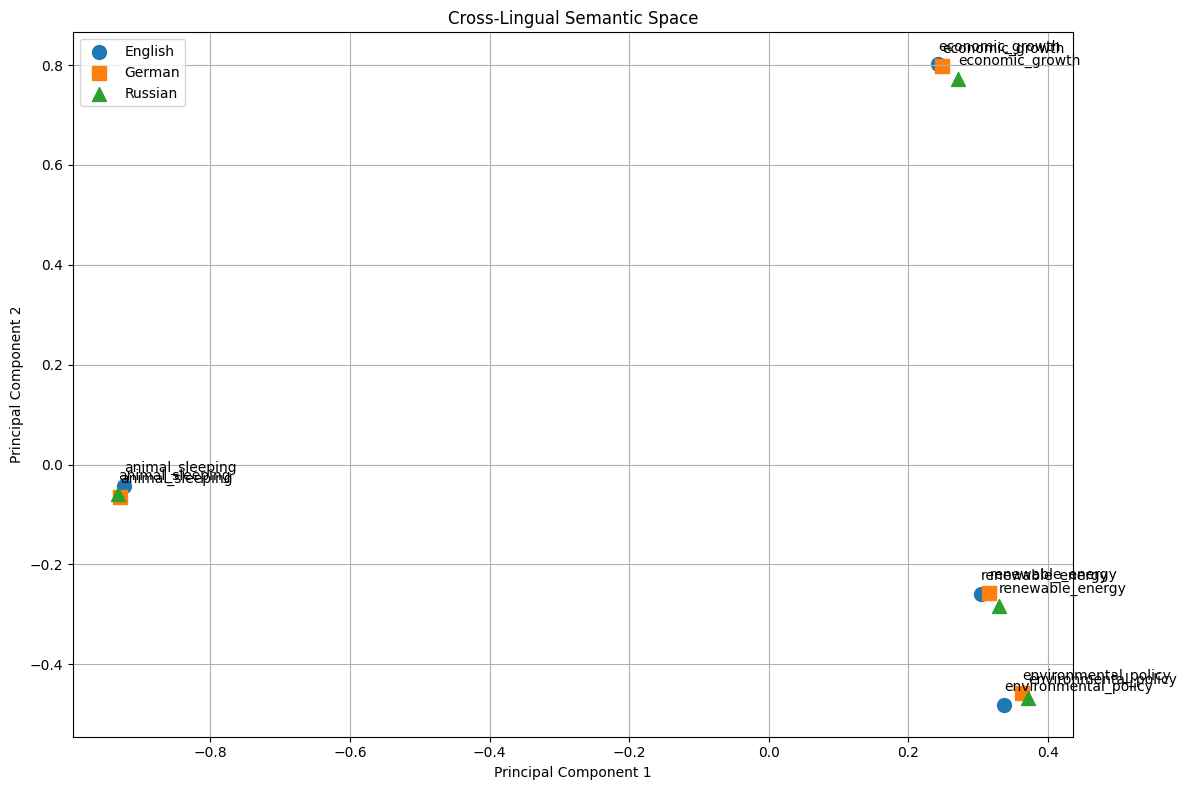

In [14]:
# Plot text in reduced semantic space
# Inspect whether language identity or semantic concept appears to dominate 
# the spatial organization.

markers = {"English": "o", "German": "s", "Russian": "^"}

plt.figure(figsize = (12, 8))

for language in documents["language"].unique():
    language_data = documents[documents["language"] == language]

    plt.scatter(
        language_data["PC1"],
        language_data["PC2"],
        marker = markers[language],
        s = 100,
        label = language
    )

    for i, row in language_data.iterrows():
        plt.annotate(
            row["concept"],
            (row["PC1"], row["PC2"]),
            textcoords = "offset points",
            xytext = (0, 10),

        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Cross-Lingual Semantic Space")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualize Semantic Concepts

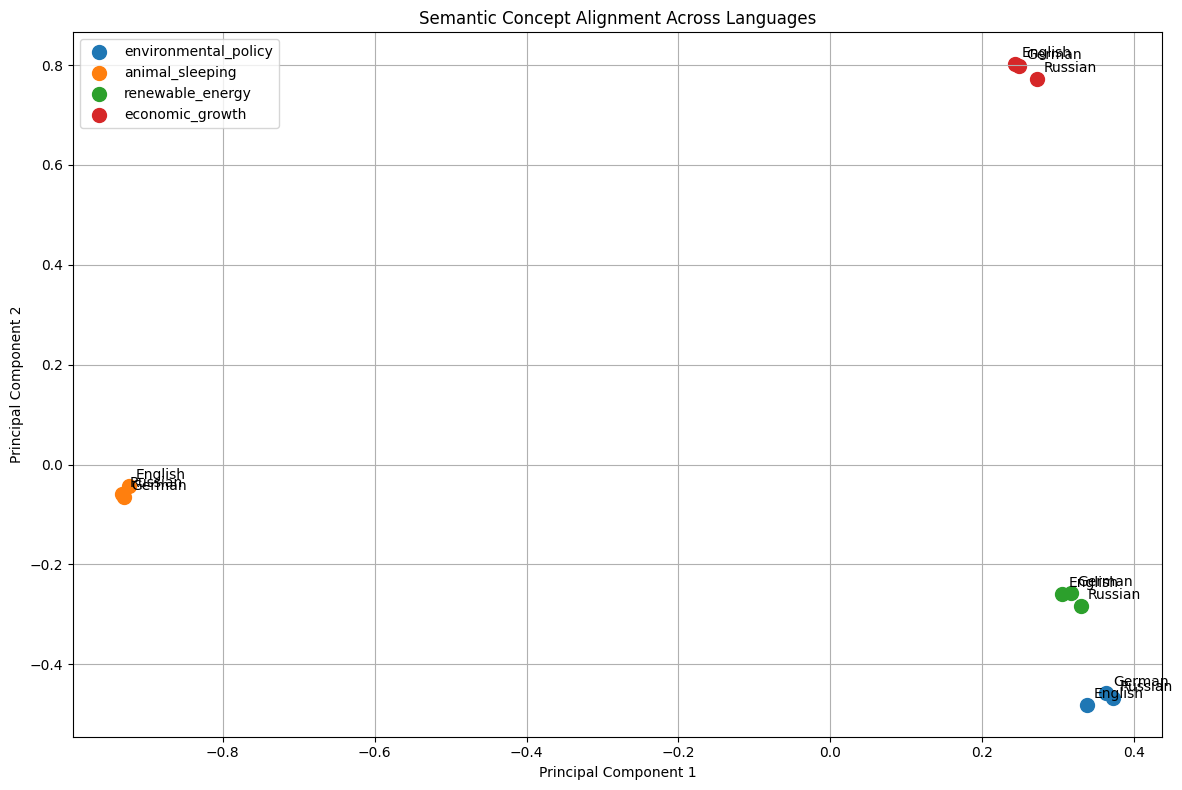

In [15]:
# This visualization emphasizes semantic concepts rather than language.
# Sentences representing the same concept should ideally appear near one 
# another even when they belong to different languages.

plt.figure(figsize = (12, 8))

for concept in documents["concept"].unique():
    concept_data = documents[
        documents["concept"] == concept
    ]

    plt.scatter(
        concept_data["PC1"],
        concept_data["PC2"],
        s = 100,
        label = concept
    )

    for _, row in concept_data.iterrows():
        plt.annotate(
            row["language"],
            (
                row["PC1"],
                row["PC2"]
            ),
            xytext = (5, 5),
            textcoords = "offset points"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Semantic Concept Alignment Across Languages")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Measure Within-Concpet Distances

In [16]:
# Caluclate average Euclidean distance between languages for each semantic 
# concept in the reduced space.
# Smaller distances indicate better alignment of semantic concepts across 
# languages.

alignment_results = []

for concept in documents["concept"].unique():
    concept_data = documents[
        documents["concept"] == concept
    ]

    for i in range(len(concept_data)):
        for j in range(i + 1, len(concept_data)):

            first = concept_data.iloc[i]
            second = concept_data.iloc[j]

            distance = (
                (
                    (first["PC1"] - second["PC1"]) ** 2
                    +
                    (first["PC2"] - second["PC2"]) ** 2
                ) ** 0.5
            )

            alignment_results.append(
                {
                    "concept": concept,
                    "language_pair": (
                        f"{first['language']} → "
                        f"{second['language']}"
                    ),
                    "distance": distance
                }
            )

alignment_df = pd.DataFrame(alignment_results)

alignment_df.sort_values(
    by = "distance"
)

,concept,language_pair,distance
5,animal_sleeping,German → Russian,0.006367
9,economic_growth,English → German,0.007351
2,environmental_policy,German → Russian,0.012025
6,renewable_energy,English → German,0.012041
4,animal_sleeping,English → Russian,0.018011
3,animal_sleeping,English → German,0.022591
8,renewable_energy,German → Russian,0.029927
11,economic_growth,German → Russian,0.033802
0,environmental_policy,English → German,0.034154
7,renewable_energy,English → Russian,0.035001


### Calculate Average Aligment Distance

In [18]:
# Calculate the average distance between equivalent concepts.
# This provides a simple quantitative summary of the visualization.

average_alignment_distance = alignment_df["distance"].mean()

print(f"Average cross-lingual distance: {average_alignment_distance:.4f}")

Average cross-lingual distance: 0.0240


### Examine Language-Pair Alignment

In [19]:
# Aggregate distances by language pair.
# This helps identify whether certain language pairs are represented more 
# closely than others.

language_pair_alignment = (
    alignment_df
    .groupby("language_pair")["distance"]
    .mean()
    .sort_values()
)

language_pair_alignment

language_pair
English → German     0.019034
German → Russian     0.020530
English → Russian    0.032582
Name: distance, dtype: float32

### Interpreting this experiment

This experiment is a cross-lingual sanity check for the multilingual encoder. It asks whether sentences that mean the same thing in different languages are mapped to nearby points in the embedding space, even when their vocabulary, word order, and morphology differ.

- If English, German, and Russian examples for the same concept cluster together, then the model is learning shared semantic structure instead of language-specific patterns.
- If different concepts remain separated, then the encoder is preserving conceptual distinctions across languages.
- If the same concept spans a wide area across languages, then the model may be sensitive to word form, syntax, or translation differences rather than a stable cross-lingual meaning.

The PCA projection helps us inspect these patterns visually, but it is only a 2D approximation of a much higher-dimensional embedding space. This means the plot should be treated as a qualitative diagnostic, not a definitive proof of alignment.

#### Cross-lingual interpretation

- English, German, and Russian sentences are compared in the same semantic space, so their relative locations reveal whether the model treats them as conceptually similar.
- A short distance between translations of the same idea suggests successful multilingual alignment.
- A larger distance may reflect differences in morphology, syntax, or lexicalization across languages, especially for concepts that are harder to express in a parallel way.
- The language-pair averages also help reveal whether certain combinations, such as English–German or English–Russian, are closer than others in semantic space.

### Connection to the relevant research questions

This experiment directly connects to the project’s central question: whether multilingual embeddings align meaning across languages rather than merely preserving language identity.

- Q1: Can multilingual embeddings align meaning across languages?
  - This notebook compares semantically equivalent English, German, and Russian sentences in the same embedding space.
  - If the points for the same concept cluster together across languages, then the model is learning shared semantic structure.

- Q2: How does morphology affect semantic retrieval?
  - German compounds and Russian inflectional forms change surface form while preserving meaning.
  - This visualization helps reveal whether the embedding space remains conceptually coherent despite morphological differences.

- Q3: Does linguistic preprocessing improve retrieval?
  - If concept clusters remain tight across languages, then preprocessing and representation choices are likely supporting cross-lingual semantic alignment.
  - If alignment is weak, then additional linguistic normalization or morphological handling may be necessary.

- Q4: How do retrieval failures reflect linguistic differences?
  - Large cross-lingual distances or inconsistent clusters can signal that morphology, word order, or lexical variation is affecting retrieval quality.
  - In this sense, the notebook provides a visual diagnostic for the types of linguistic mismatch discussed in the README.

Overall, this notebook acts as a direct bridge between the README research questions and the actual multilingual embedding analysis: it asks whether meaning remains stable across languages in the same semantic space.